# `02-llm.ipynb`
- 기존 기계적인 워크플로우 -> LLM을 삽입

```mermaid
flowchart TD
START --> analyze_sentiment

    analyze_sentiment --> |positive| positive_node
    analyze_sne
```

In [78]:
from dotenv import load_dotenv

load_dotenv()

True

In [79]:
# State 정의
from typing import TypedDict, Literal, NotRequired

class TeacherState(TypedDict):
    user_input: str  # 사용자 입력
    sentiment: NotRequired[Literal['positive', 'negative', 'agressive']]  # 감정 분석
    core_msg: NotRequired[str]    # 핵심 메세지
    response: NotRequired[str]    # 최종 답변
    warning_count: NotRequired[int]

In [80]:
from langchain.chat_models import init_chat_model

llm = init_chat_model('gpt-4.1-mini')

# LLM 초기화 + 감정분석 Node
def analyze_sentiment(state: TeacherState) -> Literal['positive', 'negative', 'aggressive']:
    prompt = f'''
    아래 문장의 감정을 분류.
    아래 3가지 중 1가지로 판단
    positive
    negative
    aggressive
                 
    문장: {state['user_input']}
    '''

    result = llm.invoke(prompt)

    return {'sentiment': result.content}

In [81]:
import random

# 나머지 노드
def positive_node(state: TeacherState):
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

def negative_node(state: TeacherState):
    msgs = ['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

warning_count = 0
def aggressive_node(state: TeacherState):
    # dic.get(a, b) -> key a가 있으면, 해당 value. key a가 없으면 b 나옴
    warning_count = state['warning_count']
    warning_count += 1
    if warning_count < 3:
        return {'core_msg': '공격적인 표현은 삼가라!', 'warning_count': warning_count}
    else:
        return {'core_msg': '차단'}

In [82]:
# 완성 Node
def make_final_msg(state: TeacherState):
    prompt = f'''
    다음 사용자 입력에 맞는 답변을 생성해.
    핵심 키워드/메세지를 참조해야해. 

    사용자 입력: {state['user_input']}
    핵심 키워드: {state['core_msg']}
    '''
    result = llm.invoke(prompt)

    return {'response': result.content}

def block_user(state: TeacherState):
    return {'response':'차단됨'}
    
        

In [83]:
def router_sentiment(state: TeacherState):
    return state['sentiment']

def router_warning_count(state: TeacherState):
    warning_count = state['warning_count']
    if warning_count < 3:
        return 'make_final_msg'
    else:
        return 'block_user'

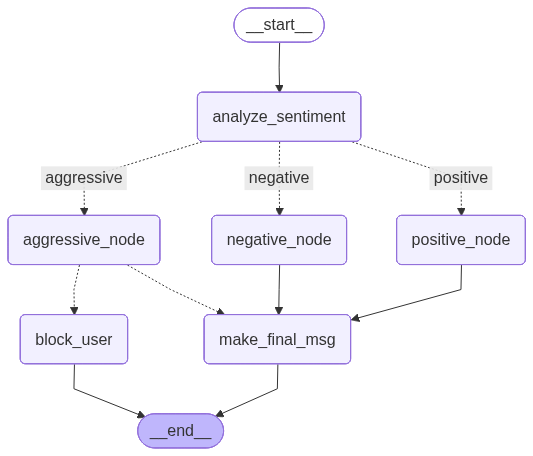

In [84]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TeacherState)

# 노드등록
graph.add_node('analyze_sentiment', analyze_sentiment)
graph.add_node('positive_node', positive_node)
graph.add_node('negative_node', negative_node)
graph.add_node('aggressive_node', aggressive_node)
graph.add_node('make_final_msg', make_final_msg)
graph.add_node('block_user', block_user)

# 엣지등록
graph.add_edge(START, 'analyze_sentiment')
graph.add_conditional_edges(
    'analyze_sentiment',
    router_sentiment,
    {       # router 결과값: 다음 노드명
        'positive': 'positive_node',
        'negative': 'negative_node',
        'aggressive': 'aggressive_node'
    }
)
graph.add_edge('positive_node', 'make_final_msg')
graph.add_edge('negative_node', 'make_final_msg')
graph.add_conditional_edges('aggressive_node', 
                            router_warning_count,
                            {
                                'make_final_msg':'make_final_msg',
                                'block_user': 'block_user'
                            }
                            )
graph.add_edge('make_final_msg', END)
graph.add_edge('block_user', END)

app = graph.compile()
app

In [86]:
app.invoke({'user_input': '바보', 'warning_count': 0}) # 답변 정상

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '공격적인 표현은 삼가라!',
 'response': '서로를 존중하는 마음이 더욱 좋은 대화를 만듭니다. 공격적인 표현은 삼가 주세요!',
 'warning_count': 1}

In [ ]:
app.invoke({'user_input': '바보', 'warning_count': 1}) # 답변 정상

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '공격적인 표현은 삼가라!',
 'response': '서로를 존중하는 마음이 중요해요. 더 좋은 대화를 나누기 위해 부드러운 표현을 사용해 주세요!',
 'warning_count': 1}

In [87]:
app.invoke({'user_input': '바보', 'warning_count': 3}) # 차단

{'user_input': '바보',
 'sentiment': 'aggressive',
 'core_msg': '차단',
 'response': '차단됨',
 'warning_count': 3}

In [88]:
app.invoke({'user_input': '기분이 좋아', 'warning_count': 3}) # 답변 정상

{'user_input': '기분이 좋아',
 'sentiment': 'positive',
 'core_msg': '멋져',
 'response': '멋져요! 기분이 좋을 때가 가장 행복한 순간이죠. 계속 좋은 기분 유지하세요!',
 'warning_count': 3}